In [9]:
import pandas as pd
import numpy as np
import os
import scanpy as sc
import anndata as ad

In [65]:
dataset = "Melanoma_Oct2522"

In [66]:
dfs = []
path = f"/Users/lukashat/sds_mount/sds/sd22c003/phenotyping_benchmark/datasets/ManualLabels/{dataset}/quantification"
for df in os.listdir(path):
    if df.endswith(".csv"):
        image_name = df.split(".")[0]
        df = pd.read_csv(os.path.join(path, df))
        df['sample_id'] = image_name
        df = df.rename(columns={"CellID": "cell_id", "X_centroid": "x", "Y_centroid": "y"})
        dfs.append(df)
        df_concat = pd.concat(dfs, ignore_index=True)



In [70]:
df_concat

,cell_id,CD20,HLA1,CD163,CD31,CD8,PDL1,CD103,HLADRDPDQ,CD45RO,...,x,y,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,sample_id
0,1,0.0,0.476471,0.000000,0.0,0.000000,0.047059,0.0,0.000000,0.000000,...,312.723529,5.364706,170.0,19.345523,13.866577,0.697294,0.850000,0.596491,0.821796,Slide04_Point024
1,2,0.0,0.364238,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,360.311258,3.251656,151.0,27.952821,8.555056,0.952014,0.820652,0.508418,-1.333372,Slide04_Point024
2,3,0.0,0.365517,0.027586,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,904.034483,2.544828,145.0,25.776904,7.641767,0.955046,0.935484,0.697115,-1.559193,Slide04_Point024
3,4,0.0,0.256000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,236.516000,3.980000,250.0,31.580917,10.515285,0.942940,0.950570,0.833333,-1.502132,Slide04_Point024
4,5,0.0,0.365639,0.000000,0.0,0.000000,0.083700,0.0,0.000000,0.000000,...,81.176211,4.356828,227.0,26.770468,11.398936,0.904816,0.961864,0.756667,1.427979,Slide04_Point024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21199,1697,0.0,0.672922,0.029491,0.0,0.000000,0.000000,0.0,0.453083,0.008043,...,264.396783,541.761394,373.0,25.133727,19.779411,0.616995,0.944304,0.652098,1.555398,Slide11_TMA086_Point104
21200,1698,0.0,0.410211,0.079225,0.0,0.000000,0.000000,0.0,0.112676,0.149648,...,154.325704,597.253521,568.0,30.780966,23.699485,0.638117,0.956229,0.732903,1.155607,Slide11_TMA086_Point104
21201,1699,0.0,0.651724,0.048276,0.0,0.137931,0.000000,0.0,0.072414,0.051724,...,174.413793,587.572414,290.0,21.510297,17.405534,0.587572,0.932476,0.663616,1.479694,Slide11_TMA086_Point104
21202,1700,0.0,0.593220,0.169492,0.0,0.023729,0.000000,0.0,0.067797,0.200000,...,109.891525,780.433898,295.0,22.100619,17.707876,0.598345,0.957792,0.641304,0.159275,Slide11_TMA086_Point104


In [67]:
df_labels = pd.read_csv(f'/Users/lukashat/Documents/PhD_Schapiro/Projects/phenotype_benchmark/CellTuneDepot/ManualLabels/{dataset}/Tables/Labels.csv')
df_labels = df_labels.rename(columns={"cellID": "cell_id", "image": "sample_id", "class": "cell_type"})

In [69]:
df_labels

,sample_id,cell_id,cell_type
0,Slide01_Point001,1,Myeloid
1,Slide01_Point001,2,Unidentified
2,Slide01_Point001,3,Tumor
3,Slide01_Point001,4,Tumor
4,Slide01_Point001,5,Myeloid
...,...,...,...
21199,Slide11_TMA086_Point104,1697,Tumor
21200,Slide11_TMA086_Point104,1698,Myeloid
21201,Slide11_TMA086_Point104,1699,CD8T
21202,Slide11_TMA086_Point104,1700,Treg


In [68]:
df_united = pd.merge(df_concat, df_labels, on=["cell_id", "sample_id"], how="inner")

In [53]:
df_united

,cell_id,CD20,HLA1,CD163,Mucin,CD31,CD8,PDL1,CD45RA,Lysozyme,...,y,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,sample_id,cell_type
0,145,0.000000,0.135897,0.0,6.137821,0.0,0.000000,0.0,0.000000,0.000000,...,37.053205,1560.0,56.124257,37.065134,0.750903,0.919811,0.795512,-1.554369,GVHD_22_FOV_2,Goblet
1,149,0.000000,0.000000,0.0,6.180022,0.0,0.000000,0.0,0.000000,0.000000,...,45.680571,911.0,41.550107,28.494863,0.727795,0.909182,0.665449,0.773492,GVHD_22_FOV_2,Goblet
2,150,0.000000,0.595847,0.0,2.803514,0.0,0.000000,0.0,0.000000,0.000000,...,48.824281,626.0,35.304232,22.993594,0.758822,0.944193,0.715429,0.239979,GVHD_22_FOV_2,Goblet
3,153,0.000000,0.014621,0.0,4.837076,0.0,0.000000,0.0,0.000000,0.000000,...,50.101828,1915.0,77.761225,31.939421,0.911754,0.883710,0.497403,0.599097,GVHD_22_FOV_2,Goblet
4,159,0.000000,0.056854,0.0,5.584112,0.0,0.000000,0.0,0.000000,0.000000,...,57.122274,1284.0,44.209887,37.460817,0.531050,0.915835,0.700491,0.361665,GVHD_22_FOV_2,Goblet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1789,1559,0.046154,11.707692,0.0,0.000000,0.0,0.000000,0.0,0.184615,0.000000,...,346.569231,65.0,9.751255,8.557409,0.479449,0.915493,0.722222,-0.551172,GVHD_48_FOV_4,CD4T
1790,1562,0.000000,3.206897,0.0,0.000000,0.0,0.235632,0.0,0.000000,0.091954,...,348.195402,174.0,18.398351,12.136704,0.751562,0.945652,0.690476,-0.442857,GVHD_48_FOV_4,CD4T
1791,1563,0.000000,4.742690,0.0,0.000000,0.0,0.000000,0.0,0.286550,0.000000,...,348.298246,171.0,16.512254,13.457243,0.579482,0.960674,0.763393,1.047573,GVHD_48_FOV_4,CD4T
1792,1568,0.111111,5.888889,0.0,0.000000,0.0,0.000000,0.0,0.530864,0.006173,...,352.969136,162.0,16.517743,12.536647,0.651113,0.936416,0.778846,-1.278062,GVHD_48_FOV_4,Treg


In [33]:
df_united.columns

Index(['cell_id', 'CD20', 'CD163', 'Cytokeratin', 'CD34', 'CD31', 'HLADR',
       'CD44', 'CD8', 'PDL1', 'CD45RA', 'MMP9', 'DRAQ5', 'CD45RO', 'VIM',
       'CD2', 'Collagen', 'SYP', 'IDO1', 'BCAT', 'CD11c', 'SMA', 'CD11b',
       'PD1', 'CD25', 'CD194', 'VISTA', 'Ki67', 'CD7', 'CD30', 'NAKATPASE',
       'LAG3', 'CD57', 'MMP12', 'GZMB', 'GATA3', 'CD68', 'MUC1', 'CD4', 'Tbet',
       'CD21', 'BCL2', 'DNA', 'CD38', 'P53', 'CD45', 'CD138', 'CD56', 'CDX2',
       'FOXP3', 'EGFR', 'CD3', 'CD71', 'ICOS', 'PDPN', 'GFAP', 'CD5', 'CD15',
       'CHGA', 'x', 'y', 'Area', 'MajorAxisLength', 'MinorAxisLength',
       'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'sample_id',
       'cell_type'],
      dtype='object')

In [71]:
cols = df_united.columns.tolist()
cols.remove('cell_id')
chga_idx = cols.index('Orientation')
cols.insert(chga_idx + 1, 'cell_id')
df_united = df_united[cols]


In [72]:
df_united['cell_type'].value_counts()

cell_type
Myeloid           5443
Tumor             4054
CD8T              2770
Tumor_BCAT        2003
CD4T              1483
Neutrophil        1175
Bcell             1055
NKT                558
Unidentified       411
Endothelial        377
ImmuneOther        324
SMV                283
HLM                268
Treg               254
ActivatedFibro     169
MyoFibro           157
Epithelial         152
Tcell              132
Garbage             67
NK                  45
Neuron              24
Name: count, dtype: int64

In [79]:
X_columns = df_united.columns[:df_united.columns.get_loc('x')]
obs_columns = df_united.columns[df_united.columns.get_loc('x'):]
adata = ad.AnnData(
    X=df_united[X_columns],
    obs=df_united[obs_columns],
    var=pd.DataFrame(index=X_columns)
)

/Users/lukashat/miniforge3/envs/scimap_benchmark/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [18]:
adata

AnnData object with n_obs × n_vars = 7610 × 22
    obs: 'x', 'y', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'cell_id', 'sample_id', 'cell_type'
    uns: 'dendrogram_cell_type'

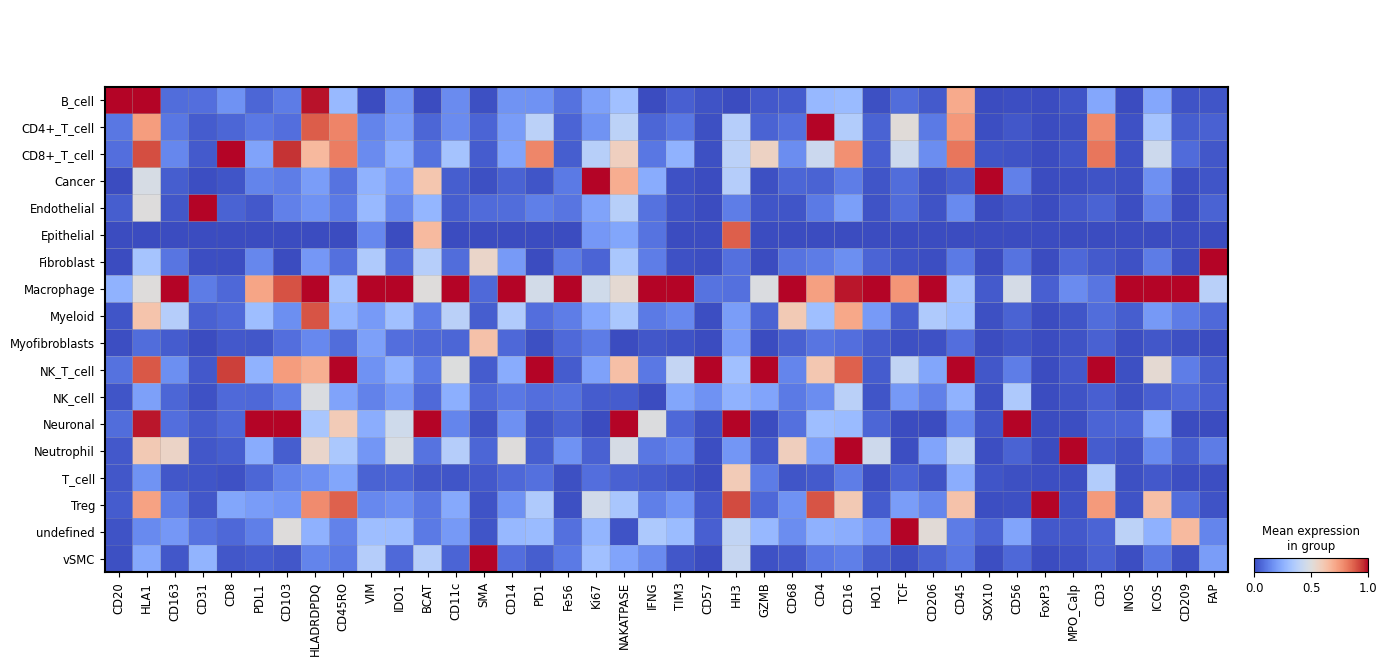

In [80]:
sc.pl.matrixplot(adata, var_names=adata.var_names, groupby='cell_type', cmap='coolwarm', use_raw=False, standard_scale='var')

In [78]:
df_united['cell_type'] = df_united['cell_type'].replace({"TumorEpithelial": "Cancer", "CD4T": "CD4+_T_cell", "CD8T": "CD8+_T_cell", "Bcell": "B_cell", "Plasma": "Plasma_cell", "Unidentified": "undefined", 
                                           "ImmuneOther": "undefined", "Mast": "Mast_cell", "CD3T": "T_cell", "DC": "Dendritic_cell", "Neuron": "Neuronal", "SMV": "vSMC",
                                           "Tumor": "Cancer","Endocrine": "Endocrine_cell", "Goblet": "Goblet_cell", "Paneth": "Paneth_cell", "ActivatedFibro": "Fibroblast", 'Garbage': "undefined",
                                           "MyoFibro": "Myofibroblasts", 'NK': "NK_cell", "NKT": "NK_T_cell", "Tcell": "T_cell", "Tumor_BCAT": "Cancer", 'HLM': "Macrophage"})

In [81]:
df_united.to_csv(os.path.join(path, f"{dataset}_quantification.csv"), index=False)